In [1]:
!pip install ucimlrepo

In [2]:
# ==========================================
# KLASIFIKASI kNN DAN DECISION TREE
# DATASET UCI WISCONSIN BREAST CANCER (id=17)
# DIAWALI DENGAN EDA
# ==========================================

# Jika belum terpasang:
# !pip install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
# ==========================================
# 1. LOAD DATASET DARI UCI
# ==========================================
dataset = fetch_ucirepo(id=17)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

# Jika y berupa DataFrame satu kolom, ubah menjadi Series
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

print("Ukuran fitur :", X.shape)
print("Ukuran target:", y.shape)

print("\n5 data pertama:")
print(X.head())

print("\nNama kelas target:")
print(y.unique())

# Encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nMapping label:")
for i, cls in enumerate(le.classes_):
    print(f"{cls} -> {i}")

Ukuran fitur : (569, 30)
Ukuran target: (569,)

5 data pertama:
   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  radius3  \
0      0.3001          0.14710     0.2419             0.07871  ...    25.38   
1      0.0869          0.07017     0.1812             0.05667  ...    24.99   
2      0.1974          0.12790     0.2069             0.05999  ...    23.57   
3      0.2414          0.10520     0.2597             0.09744  ...    14.91   
4      0.1980          0.10430     0.1809             0.05883  ...    22.54   

   texture3  perimeter3   area3  s


INFO DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 1

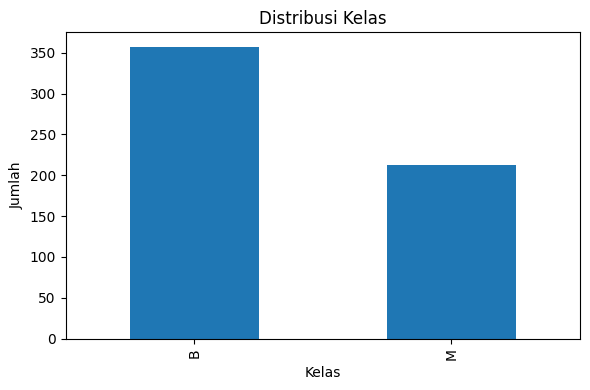

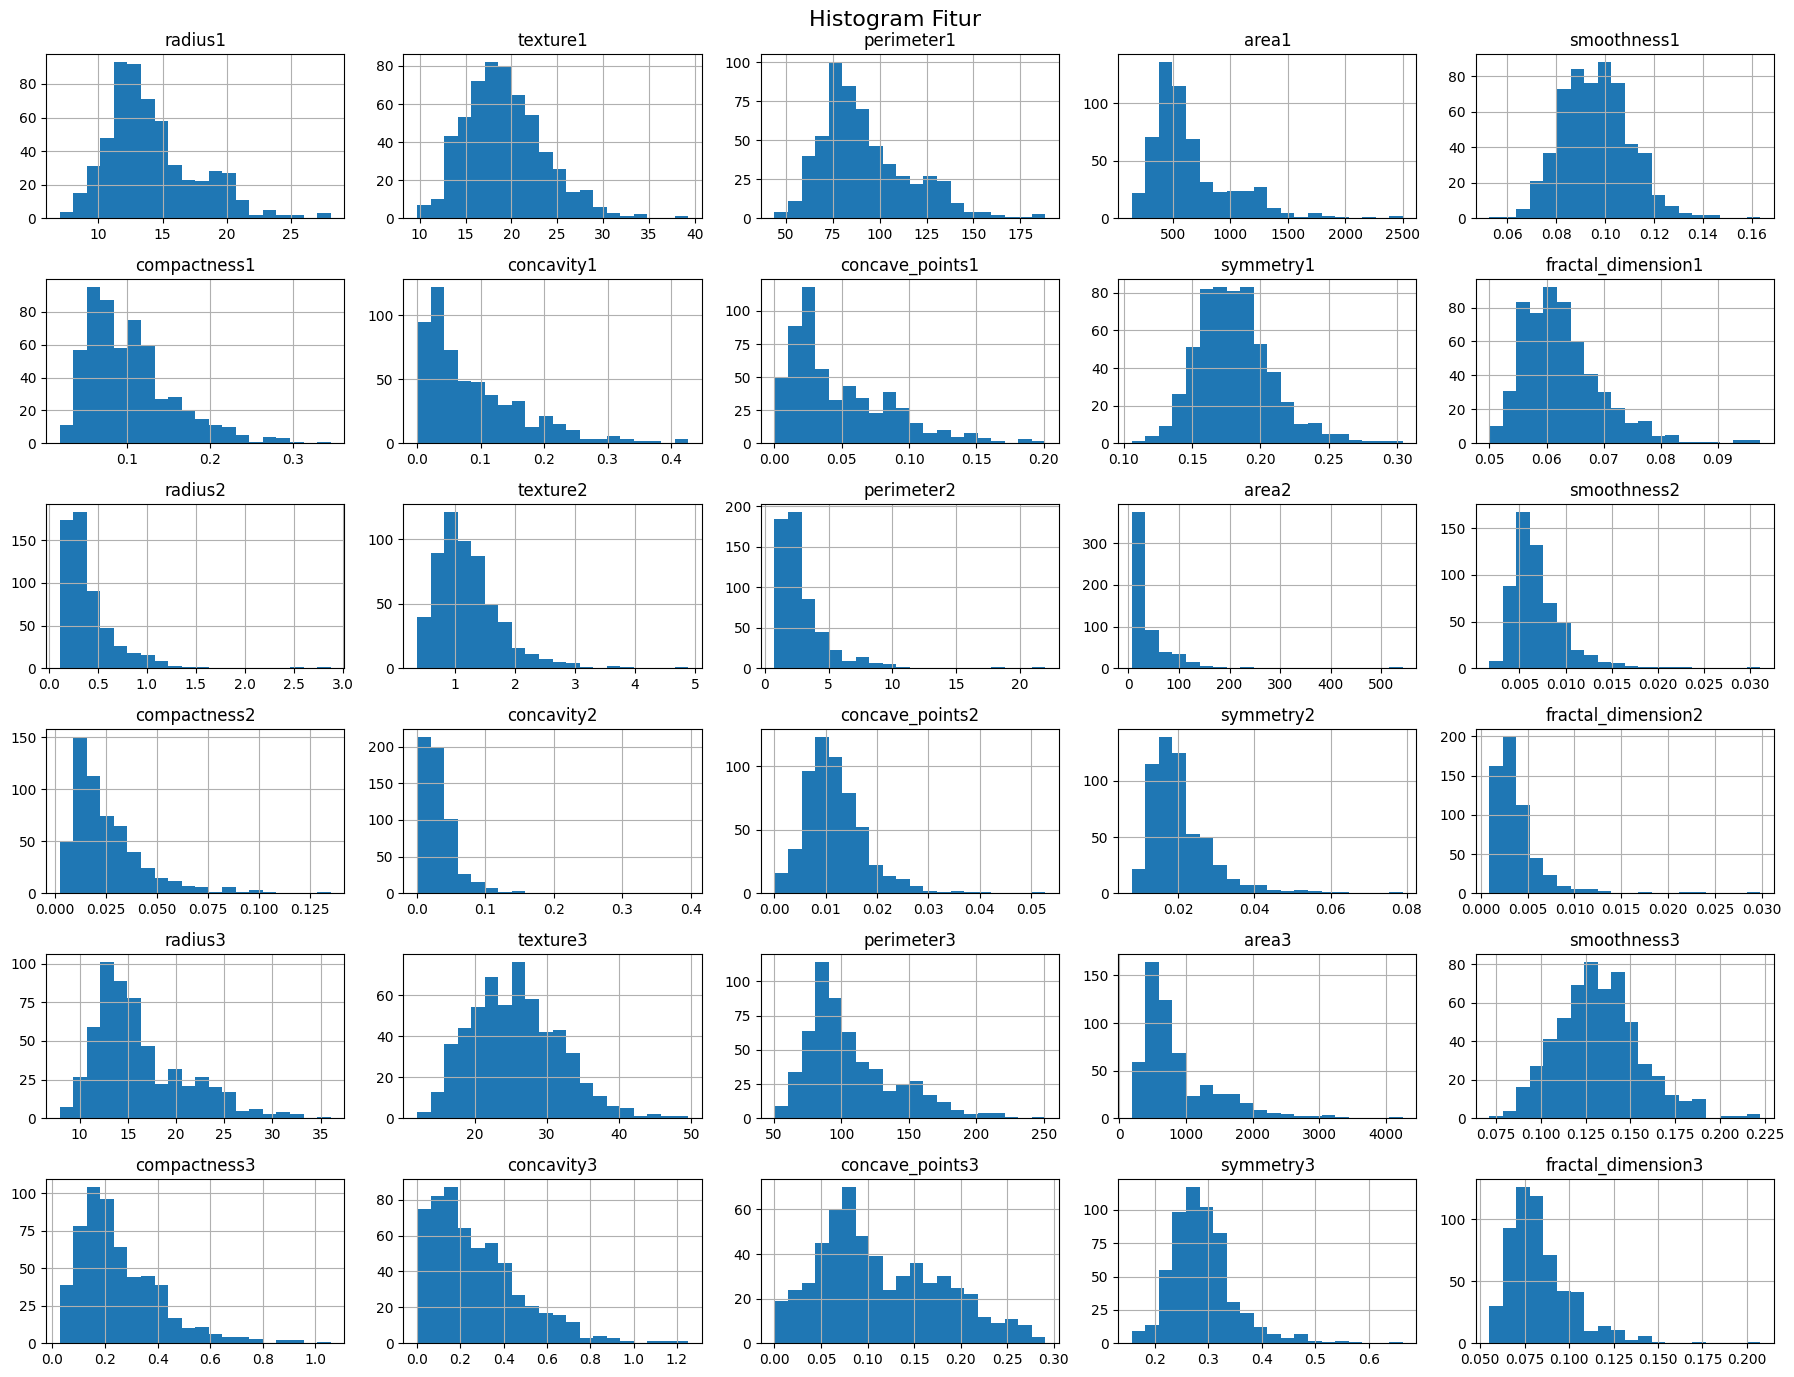

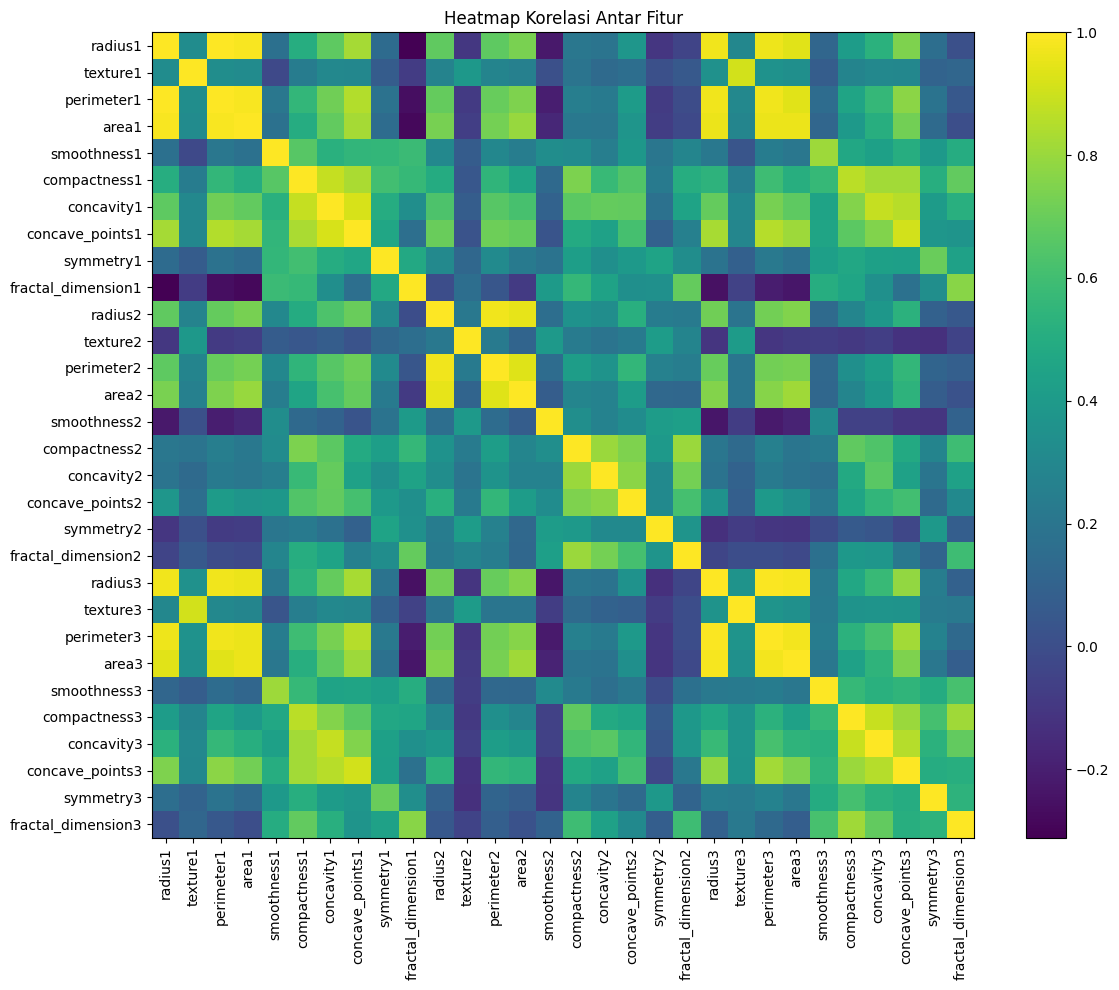


10 PASANG FITUR DENGAN KORELASI TERTINGGI
radius1     perimeter1    0.997855
perimeter3  radius3       0.993708
radius1     area1         0.987357
area1       perimeter1    0.986507
radius3     area3         0.984015
area3       perimeter3    0.977578
radius2     perimeter2    0.972794
perimeter3  perimeter1    0.970387
radius1     radius3       0.969539
perimeter1  radius3       0.969476
dtype: float64


In [5]:
# ==========================================
# 2. EDA (EXPLORATORY DATA ANALYSIS)
# ==========================================
print("\n" + "="*50)
print("INFO DATA")
print("="*50)
print(X.info())

print("\n" + "="*50)
print("STATISTIK DESKRIPTIF")
print("="*50)
print(X.describe())

print("\n" + "="*50)
print("MISSING VALUE")
print("="*50)
print(X.isnull().sum())

print("\n" + "="*50)
print("DISTRIBUSI KELAS")
print("="*50)
print(y.value_counts())

# ------------------------------------------
# Visualisasi distribusi kelas
# ------------------------------------------
plt.figure(figsize=(6, 4))
y.value_counts().plot(kind='bar')
plt.title("Distribusi Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()

# ------------------------------------------
# Histogram beberapa fitur
# ------------------------------------------
X.hist(figsize=(18, 14), bins=20)
plt.suptitle("Histogram Fitur", fontsize=16)
plt.tight_layout()
plt.show()

# ------------------------------------------
# Korelasi antar fitur
# ------------------------------------------
corr = X.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.title("Heatmap Korelasi Antar Fitur")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

# Menampilkan pasangan fitur dengan korelasi tertinggi
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]
corr_pairs = corr_pairs.sort_values(ascending=False)

print("\n" + "="*50)
print("10 PASANG FITUR DENGAN KORELASI TERTINGGI")
print("="*50)
print(corr_pairs.drop_duplicates().head(10))

In [6]:
# ==========================================
# 3. TRAIN-TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\nUkuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)


Ukuran X_train: (455, 30)
Ukuran X_test : (114, 30)



HASIL KLASIFIKASI kNN
Accuracy: 0.9561

Classification Report:
              precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



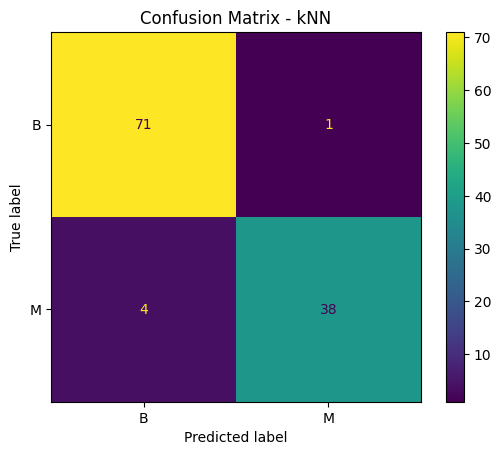

In [7]:
# ==========================================
# 4. MODEL kNN
# kNN perlu scaling
# ==========================================
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)

print("\n" + "="*50)
print("HASIL KLASIFIKASI kNN")
print("="*50)
print("Accuracy:", round(acc_knn, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=le.classes_)
disp_knn.plot()
plt.title("Confusion Matrix - kNN")
plt.show()


HASIL KLASIFIKASI DECISION TREE
Accuracy: 0.9123

Classification Report:
              precision    recall  f1-score   support

           B       0.90      0.97      0.93        72
           M       0.94      0.81      0.87        42

    accuracy                           0.91       114
   macro avg       0.92      0.89      0.90       114
weighted avg       0.91      0.91      0.91       114



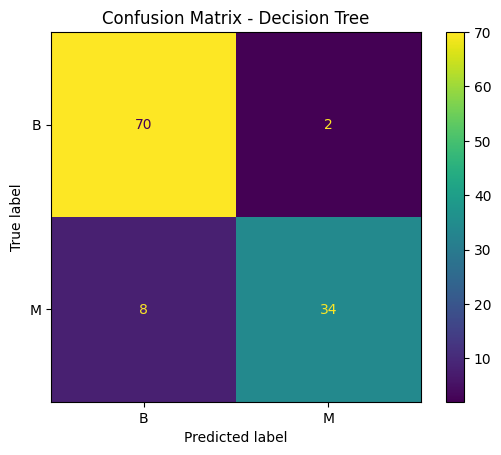

In [8]:
# ==========================================
# 5. MODEL DECISION TREE
# Decision Tree tidak wajib scaling
# ==========================================
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)

print("\n" + "="*50)
print("HASIL KLASIFIKASI DECISION TREE")
print("="*50)
print("Accuracy:", round(acc_dt, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=le.classes_)
disp_dt.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

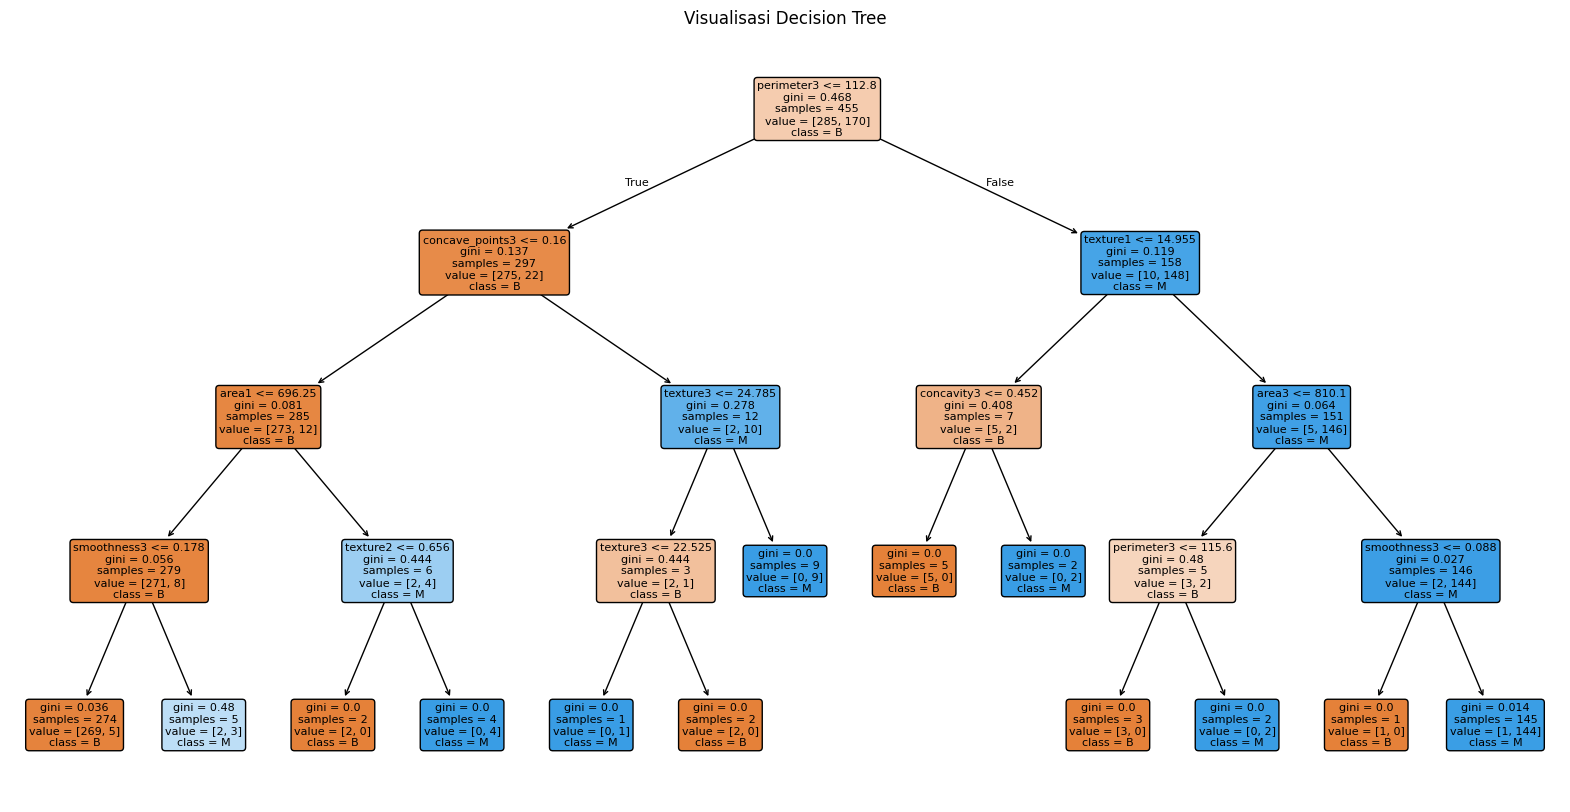

In [9]:
# ==========================================
# 6. VISUALISASI DECISION TREE
# ==========================================
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Visualisasi Decision Tree")
plt.show()


PERBANDINGAN HASIL
           Model  Accuracy
0            kNN  0.956140
1  Decision Tree  0.912281


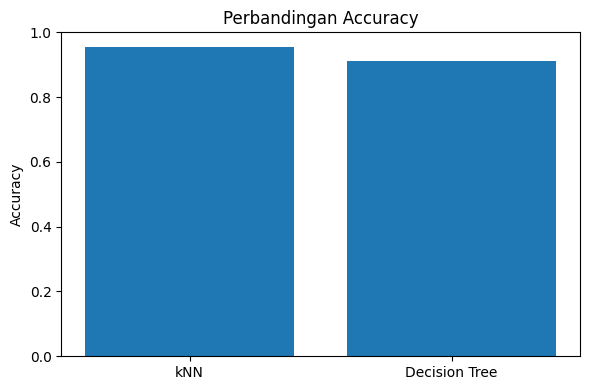

In [10]:
# ==========================================
# 7. PERBANDINGAN HASIL
# ==========================================
results = pd.DataFrame({
    "Model": ["kNN", "Decision Tree"],
    "Accuracy": [acc_knn, acc_dt]
})

print("\n" + "="*50)
print("PERBANDINGAN HASIL")
print("="*50)
print(results)

plt.figure(figsize=(6, 4))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Perbandingan Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()